# FOIA AI Chat Log Dataset Analysis

Analyzes completed FOIA responses containing government employee AI chat logs from 11 agencies.

**Data sources:** MuckRock FOIA responses (2023-2026)  
**Formats:** Copilot HTML exports, ChatGPT PDF exports, DOCX manual logs, policy documents

In [1]:
import sys
sys.path.insert(0, '../past-datasets')

from data_handler import (
    load_all_datasets, load_agency,
    conversations_to_df, messages_to_df,
    Conversation, Message
)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import re
import textwrap

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load all datasets

In [2]:
conversations = load_all_datasets(verbose=False)
conv_df = conversations_to_df(conversations)
msg_df = messages_to_df(conversations)

print(f"Total conversation entries: {len(conv_df)}")
print(f"With parseable content:     {conv_df['has_content'].sum()}")
print(f"Total messages:             {len(msg_df)}")
print(f"Unique agencies:            {conv_df['agency'].nunique()}")
print(f"Unique users:               {msg_df[msg_df['role']=='user']['user_name'].nunique()}")

Total conversation entries: 946
With parseable content:     920
Total messages:             9259
Unique agencies:            11
Unique users:               26


## 2. Overview by agency

In [3]:
agency_summary = conv_df.groupby('agency').agg(
    conversations=('has_content', 'sum'),
    total_messages=('num_messages', 'sum'),
    total_chars=('total_chars', 'sum'),
    unique_users=('user_name', 'nunique'),
    ai_tools=('ai_tool', lambda x: ', '.join(sorted(set(str(v) for v in x if pd.notna(v) and v)))),
    formats=('format_type', lambda x: ', '.join(sorted(set(x)))),
).sort_values('total_messages', ascending=False)

agency_summary['avg_msgs_per_convo'] = (agency_summary['total_messages'] / agency_summary['conversations'].clip(1)).round(1)
agency_summary

,conversations,total_messages,total_chars,unique_users,ai_tools,formats,avg_msgs_per_convo
agency,,,,,,,
TxDOT,906,8206,10300895,18,"Copilot, Copilot in Excel, Copilot in OfficeCopilotSearchAnswer, Copilot in Outlook, Copilot in PowerPoint, Copilot ...",html_copilot,9.1
Minneapolis PD,2,376,537839,0,Copilot,pdf_copilot,188.0
Fort Worth (City Manager),1,319,800065,1,ChatGPT,"pdf_chatgpt, pdf_screenshot, policy_doc",319.0
Seattle Education,8,231,298952,5,ChatGPT,docx,28.9
Seattle SPD,1,104,100699,0,ChatGPT,"image_screenshot, pdf_chatgpt, pdf_garbled, policy_doc",104.0
Kent PD,2,23,34834,2,ChatGPT,"docx, pdf_chatgpt, pdf_screenshot, policy_doc",11.5
CFPB,0,0,0,0,,"pdf_screenshot, policy_doc",0.0
CFTC,0,0,0,0,,"pdf_screenshot, policy_doc",0.0
Fort Worth (City Attorney),0,0,0,0,,"pdf_screenshot, policy_doc",0.0


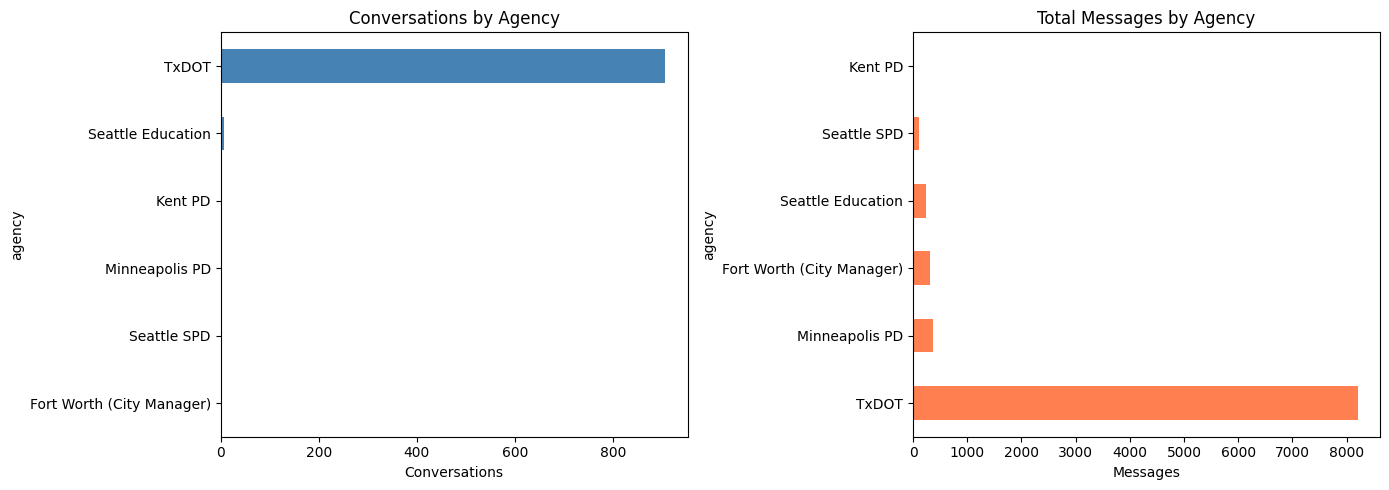

In [4]:
# Conversations and messages by agency (parseable only)
parseable = conv_df[conv_df['has_content']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

agency_counts = parseable['agency'].value_counts()
agency_counts.plot.barh(ax=ax1, color='steelblue')
ax1.set_xlabel('Conversations')
ax1.set_title('Conversations by Agency')
ax1.invert_yaxis()

msg_counts = msg_df.groupby('agency').size().sort_values(ascending=True)
msg_counts.plot.barh(ax=ax2, color='coral')
ax2.set_xlabel('Messages')
ax2.set_title('Total Messages by Agency')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Format breakdown

In [5]:
format_summary = conv_df.groupby('format_type').agg(
    count=('has_content', 'size'),
    parseable=('has_content', 'sum'),
    total_messages=('num_messages', 'sum'),
    agencies=('agency', lambda x: ', '.join(sorted(set(x)))),
).sort_values('count', ascending=False)
format_summary

,count,parseable,total_messages,agencies
format_type,,,,
html_copilot,906,906,8206,TxDOT
policy_doc,14,0,0,"CFPB, CFTC, Fort Worth (City Attorney), Fort Worth (City Manager), Kent PD, SEC, Seattle SPD"
pdf_screenshot,10,0,0,"CFPB, CFTC, Fort Worth (City Attorney), Fort Worth (City Manager), Kent PD, SEC, Spokane PD"
docx,9,9,232,"Kent PD, Seattle Education"
pdf_chatgpt,3,3,445,"Fort Worth (City Manager), Kent PD, Seattle SPD"
pdf_copilot,2,2,376,Minneapolis PD
image_screenshot,1,0,0,Seattle SPD
pdf_garbled,1,0,0,Seattle SPD


## 4. AI tools used

In [6]:
tool_df = conv_df[conv_df['ai_tool'].notna() & conv_df['has_content']]
tool_counts = tool_df.groupby('ai_tool').agg(
    conversations=('has_content', 'sum'),
    messages=('num_messages', 'sum'),
    agencies=('agency', lambda x: ', '.join(sorted(set(x)))),
).sort_values('conversations', ascending=False)
tool_counts

,conversations,messages,agencies
ai_tool,,,
Microsoft Copilot,346,3576,TxDOT
Copilot in Outlook,270,2271,TxDOT
Microsoft 365 Chat,203,1904,TxDOT
Copilot in Word,36,223,TxDOT
Copilot in PowerPoint,22,100,TxDOT
Copilot,14,389,"Minneapolis PD, TxDOT"
ChatGPT,12,677,"Fort Worth (City Manager), Kent PD, Seattle Education, Seattle SPD"
Copilot in Excel,8,95,TxDOT
Copilot in Teams,5,14,TxDOT


## 5. User analysis

In [7]:
user_df = conv_df[conv_df['user_name'].notna() & conv_df['has_content']]
user_summary = user_df.groupby(['agency', 'user_name']).agg(
    conversations=('has_content', 'sum'),
    total_messages=('num_messages', 'sum'),
    total_chars=('total_chars', 'sum'),
    ai_tool=('ai_tool', 'first'),
).sort_values('total_messages', ascending=False)

print(f"Identified {len(user_summary)} unique users across all agencies\n")
user_summary.head(20)

Identified 26 unique users across all agencies



conversations  total_messages  \
agency                    user_name                                           
TxDOT                     Cody Thomas                   282            3314   
                          Jackie Myrick                 119            1496   
                          Gabriela Rios                 182            1395   
                          Carla Hammond                  83             519   
                          Heath Bozeman                  61             476   
Fort Worth (City Manager) Chat                            1             319   
Seattle Education         Swift                           1             223   
TxDOT                     Anthony Strickland             16             148   
                          Stephen Kasberg                21             141   
                          Kim Greener                    18             118   
                          Aaron Lenz                     22             117   
                          Oscar Ramirez                  19             113   
                          Lisa McNeill                   26              84   
                          William Snider                 12              65   
                          Ed Adcock                       8              60   
                          Ben Coker                      15              50   
                          Patrina Hein                    7              38   
                          Michael Bolin                   3              23   
Kent PD                   Hemmen                          1              22   
TxDOT                     Will Snider                     1               9   

                                              total_chars  \
agency                    user_name                         
TxDOT                     Cody Thomas             2385727   
                          Jackie Myrick           1500685   
                          Gabriela Rios           1556220   
                          Carla Hammond             99972   
                          Heath Bozeman            758957   
Fort Worth (City Manager) Chat                     800065   
Seattle Education         Swift                    246626   
TxDOT                     Anthony Strickland       204034   
                          Stephen Kasberg          457990   
                          Kim Greener              111700   
                          Aaron Lenz                78270   
                          Oscar Ramirez            181943   
                          Lisa McNeill            2630433   
                          William Snider           110810   
                          Ed Adcock                113578   
                          Ben Coker                 37883   
                          Patrina Hein              17636   
                          Michael Bolin              6407   
Kent PD                   Hemmen                    33532   
TxDOT                     Will Snider               30189   

                                                            ai_tool  
agency                    user_name                                  
TxDOT                     Cody Thomas            Microsoft 365 Chat  
                          Jackie Myrick           Microsoft Copilot  
                          Gabriela Rios          Microsoft 365 Chat  
                          Carla Hammond                     Copilot  
                          Heath Bozeman           Microsoft Copilot  
Fort Worth (City Manager) Chat                              ChatGPT  
Seattle Education         Swift                             ChatGPT  
TxDOT                     Anthony Strickland     Microsoft 365 Chat  
                          Stephen Kasberg        Microsoft 365 Chat  
                          Kim Greener            Copilot in Outlook  
                          Aaron Lenz              Microsoft Copilot  
                          Oscar Ramirez       Copilot 

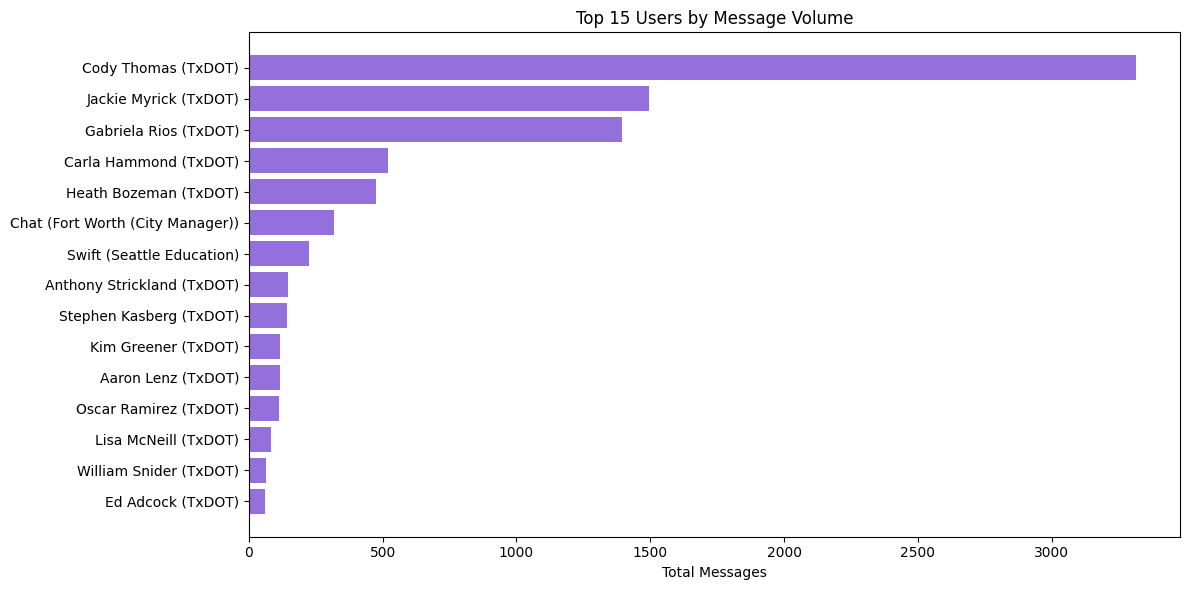

In [8]:
# Top users by message volume
top_users = user_summary.head(15).reset_index()
labels = top_users['user_name'] + ' (' + top_users['agency'] + ')'

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_users)), top_users['total_messages'], color='mediumpurple')
ax.set_yticks(range(len(top_users)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Total Messages')
ax.set_title('Top 15 Users by Message Volume')
plt.tight_layout()
plt.show()

## 6. Conversation topics

In [9]:
# Extract topics from conversation titles
titled = conv_df[conv_df['title'].notna() & conv_df['has_content']].copy()
print(f"{len(titled)} conversations have titles\n")
print("Sample titles:")
for _, row in titled.sample(min(20, len(titled)), random_state=42).iterrows():
    print(f"  [{row['agency']}] {row['title'][:100]}")

909 conversations have titles

Sample titles:
  [TxDOT] what action does a txdot recordkeeper when a copy 
  [TxDOT] Suggested drafts 24 1
  [TxDOT] Please create a comprehensive but high-level check
  [TxDOT]  fileNameFlarginssenstensin.pptx d..
  [TxDOT] compose an email to the Abilene District stating I
  [TxDOT] make this more concise Active projects are being 
  [TxDOT] Summarize 1 1
  [TxDOT] I ve been tasked with developing a TxDOT SME resou
  [TxDOT] write a directive sentence that explains when paym
  [TxDOT]   areaTone shortFeedbackAdd war..
  [TxDOT] Summarize this email 3
  [Kent PD] Detective Dress Code Guidelines
  [TxDOT] Clarifying Engine Ensight vs Engie Insight Name
  [TxDOT] For an asphaltic concrete paver  what is the minim
  [TxDOT] Is there a better way to say that I believe I have
  [TxDOT]  Will follow up Appreciate the update..
  [TxDOT] Can you condense this into fewer bullets by combin
  [TxDOT] Suggested drafts 2
  [TxDOT] When are remaining months of barric

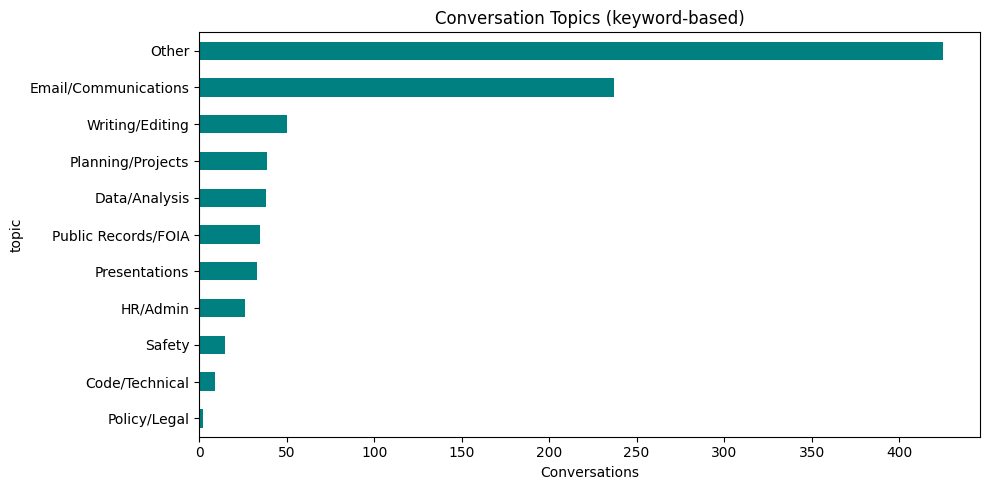

In [10]:
# Simple keyword-based topic categorization
TOPIC_KEYWORDS = {
    'Email/Communications': ['email', 'draft', 'compose', 'message', 'reply', 'respond', 'letter', 'memo'],
    'Safety': ['safety', 'hazard', 'incident', 'osha', 'ppe', 'injury'],
    'Data/Analysis': ['data', 'analy', 'chart', 'graph', 'excel', 'spreadsheet', 'workbook', 'sql', 'database'],
    'Writing/Editing': ['write', 'rewrite', 'edit', 'proofread', 'grammar', 'summarize', 'summary', 'paragraph'],
    'Presentations': ['presentation', 'powerpoint', 'slide', 'ppt'],
    'Code/Technical': ['code', 'python', 'script', 'function', 'programming', 'html', 'css', 'api', 'sql'],
    'Policy/Legal': ['policy', 'regulation', 'compliance', 'legal', 'law', 'ordinance', 'statute'],
    'HR/Admin': ['employee', 'hiring', 'interview', 'resume', 'performance', 'onboarding', 'training'],
    'Planning/Projects': ['project', 'plan', 'budget', 'timeline', 'schedule', 'milestone', 'capital'],
    'Public Records/FOIA': ['record', 'foia', 'public record', 'disclosure', 'request'],
}

def categorize_topic(title):
    if not title:
        return 'Unknown'
    title_lower = title.lower()
    for topic, keywords in TOPIC_KEYWORDS.items():
        if any(kw in title_lower for kw in keywords):
            return topic
    return 'Other'

titled['topic'] = titled['title'].apply(categorize_topic)

fig, ax = plt.subplots(figsize=(10, 5))
topic_counts = titled['topic'].value_counts()
topic_counts.plot.barh(ax=ax, color='teal')
ax.set_xlabel('Conversations')
ax.set_title('Conversation Topics (keyword-based)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
# Topic breakdown by agency
topic_agency = titled.groupby(['agency', 'topic']).size().unstack(fill_value=0)
topic_agency

topic,Code/Technical,Data/Analysis,Email/Communications,HR/Admin,Other,Planning/Projects,Policy/Legal,Presentations,Public Records/FOIA,Safety,Writing/Editing
agency,,,,,,,,,,,
Fort Worth (City Manager),0,0,0,0,1,0,0,0,0,0,0
Kent PD,1,0,0,0,0,0,0,0,0,0,0
Seattle SPD,0,0,0,0,1,0,0,0,0,0,0
TxDOT,8,38,237,26,423,39,2,33,35,15,50


## 6b. Topic Modeling of Starting Messages

Uses sentence embeddings (SBERT) + UMAP + HDBSCAN for topic discovery on the first user message of each conversation — i.e., what people actually ask AI for.

In [ ]:
# Extract first user message from each conversation as the "starting message"
starting_msgs = []
starting_meta = []

for c in conversations:
    if not c.messages:
        continue
    # Find the first user message
    for m in c.messages:
        if m.role == 'user' and len(m.content.strip()) > 10:
            # Clean Copilot JSON metadata from message content
            text = m.content
            # For Copilot HTML exports, extract just the commandText if JSON is embedded
            if '{"messageType"' in text:
                import json as _json
                try:
                    json_start = text.index('{')
                    payload = _json.loads(text[json_start:])
                    cmd = payload.get('body', {}).get('commandText', '')
                    if cmd:
                        text = cmd
                except (ValueError, _json.JSONDecodeError):
                    pass
            # Skip messages that are mostly JSON/metadata noise
            if text.startswith('{') or len(text.strip()) < 10:
                continue
            starting_msgs.append(text.strip()[:500])  # cap at 500 chars
            starting_meta.append({
                'agency': c.agency,
                'user_name': c.user_name,
                'ai_tool': c.ai_tool,
                'title': c.title,
            })
            break

print(f"Extracted {len(starting_msgs)} starting messages from {len([c for c in conversations if c.messages])} conversations with content")
print(f"\nSample starting messages:")
for i in range(min(5, len(starting_msgs))):
    print(f"  [{starting_meta[i]['agency']}] {starting_msgs[i][:120]}...")

In [ ]:
# Embed starting messages with SBERT, reduce with UMAP, cluster with HDBSCAN
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
import numpy as np

print("Encoding starting messages with SBERT...")
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(starting_msgs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embeddings.shape}")

# UMAP reduction to 2D for visualization + clustering
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
umap_2d = reducer.fit_transform(embeddings)

# Also reduce to 5D for better clustering
reducer_5d = umap.UMAP(n_components=5, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
umap_5d = reducer_5d.fit_transform(embeddings)

# HDBSCAN clustering
print("Clustering with HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3, metric='euclidean')
labels = clusterer.fit_predict(umap_5d)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"\nFound {n_clusters} topics, {n_noise} unclustered ({n_noise/len(labels)*100:.1f}%)")

In [ ]:
# Extract representative terms for each topic using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

topic_df = pd.DataFrame(starting_meta)
topic_df['text'] = starting_msgs
topic_df['topic_id'] = labels
topic_df['umap_x'] = umap_2d[:, 0]
topic_df['umap_y'] = umap_2d[:, 1]

# Get top terms per topic via c-TF-IDF (class-based TF-IDF)
def get_topic_terms(topic_df, n_terms=8):
    """Extract representative terms for each topic."""
    topics = sorted(set(topic_df['topic_id']) - {-1})
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    tfidf = vectorizer.fit_transform(topic_df['text'])
    terms = vectorizer.get_feature_names_out()
    
    topic_terms = {}
    for tid in topics:
        mask = topic_df['topic_id'] == tid
        cluster_tfidf = tfidf[mask.values].mean(axis=0).A1
        top_idx = cluster_tfidf.argsort()[-n_terms:][::-1]
        topic_terms[tid] = [(terms[i], cluster_tfidf[i]) for i in top_idx]
    return topic_terms

topic_terms = get_topic_terms(topic_df)

print(f"{'Topic':>6}  {'Size':>5}  Top Terms")
print("-" * 80)
for tid in sorted(topic_terms.keys()):
    size = (labels == tid).sum()
    terms_str = ', '.join(t for t, _ in topic_terms[tid][:6])
    print(f"  {tid:>4}  {size:>5}  {terms_str}")
unclustered = (labels == -1).sum()
print(f"    -1  {unclustered:>5}  (unclustered)")
print(f"\nTotal: {len(labels)} starting messages across {len(topic_terms)} topics")

In [ ]:
# UMAP scatter plot colored by topic
fig, ax = plt.subplots(figsize=(14, 10))

# Plot unclustered points first (gray)
mask_noise = topic_df['topic_id'] == -1
ax.scatter(topic_df.loc[mask_noise, 'umap_x'], topic_df.loc[mask_noise, 'umap_y'],
           c='lightgray', s=8, alpha=0.3, label='Unclustered')

# Plot each topic
cmap = plt.cm.tab20
topics_sorted = sorted(set(labels) - {-1})
for i, tid in enumerate(topics_sorted):
    mask = topic_df['topic_id'] == tid
    color = cmap(i % 20)
    top_term = topic_terms[tid][0][0] if tid in topic_terms else str(tid)
    label = f"T{tid}: {top_term} (n={mask.sum()})"
    ax.scatter(topic_df.loc[mask, 'umap_x'], topic_df.loc[mask, 'umap_y'],
               c=[color], s=15, alpha=0.6, label=label)

ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_title(f'Topic Map of Starting Messages ({len(topics_sorted)} topics, {len(starting_msgs)} messages)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

In [ ]:
# Topic distribution: bar chart + example messages per topic
fig, ax = plt.subplots(figsize=(12, max(4, len(topics_sorted) * 0.4)))

topic_sizes = [(tid, (labels == tid).sum()) for tid in topics_sorted]
topic_sizes.sort(key=lambda x: x[1], reverse=True)

tids = [t[0] for t in topic_sizes]
sizes = [t[1] for t in topic_sizes]
topic_labels = [', '.join(t for t, _ in topic_terms[tid][:3]) for tid in tids]

ax.barh(range(len(tids)), sizes, color=[cmap(topics_sorted.index(tid) % 20) for tid in tids])
ax.set_yticks(range(len(tids)))
ax.set_yticklabels([f"T{tid}: {lbl}" for tid, lbl in zip(tids, topic_labels)], fontsize=9)
ax.set_xlabel('Number of Starting Messages')
ax.set_title('Topic Sizes')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Show example starting messages per topic
print("\nExample starting messages per topic:\n")
for tid, size in topic_sizes[:10]:
    terms_str = ', '.join(t for t, _ in topic_terms[tid][:4])
    print(f"--- Topic {tid} ({size} msgs): {terms_str} ---")
    examples = topic_df[topic_df['topic_id'] == tid].sample(min(3, size), random_state=42)
    for _, row in examples.iterrows():
        print(f"  [{row['agency']}] {row['text'][:150]}")
    print()

In [ ]:
# Topic breakdown by agency and user
# Create human-readable topic labels
topic_label_map = {tid: ', '.join(t for t, _ in topic_terms[tid][:3]) for tid in topic_terms}
topic_label_map[-1] = 'Unclustered'

topic_df['topic_label'] = topic_df['topic_id'].map(topic_label_map)

# Topic x Agency crosstab
topic_by_agency = topic_df.groupby(['agency', 'topic_label']).size().unstack(fill_value=0)
print("Topics by agency:")
display(topic_by_agency)

# Topic x User (for top users)
top_user_topics = topic_df[topic_df['user_name'].notna()].groupby(['user_name', 'topic_label']).size().unstack(fill_value=0)
top_user_topics['total'] = top_user_topics.sum(axis=1)
top_user_topics = top_user_topics.sort_values('total', ascending=False).drop(columns='total').head(10)
print("\nTopics by user (top 10):")
display(top_user_topics)

## 7. Message length analysis

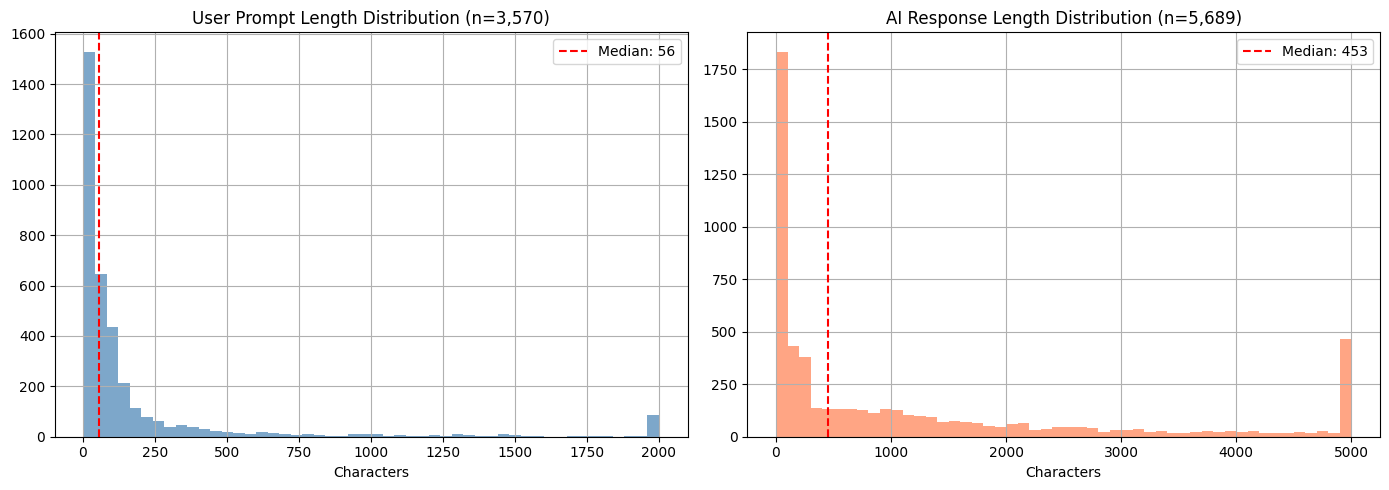

User prompt stats:
count     3570.000000
mean       240.988235
std        880.942259
min          3.000000
25%         16.000000
50%         56.000000
75%        132.000000
max      22503.000000

AI response stats:
count     5689.000000
mean      1970.988926
std       6836.171171
min          2.000000
25%         81.000000
50%        453.000000
75%       1849.000000
max      86139.000000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_msgs = msg_df[msg_df['role'] == 'user']
asst_msgs = msg_df[msg_df['role'] == 'assistant']

user_msgs['content_len'].clip(upper=2000).hist(ax=axes[0], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title(f'User Prompt Length Distribution (n={len(user_msgs):,})')
axes[0].set_xlabel('Characters')
axes[0].axvline(user_msgs['content_len'].median(), color='red', linestyle='--', label=f"Median: {user_msgs['content_len'].median():.0f}")
axes[0].legend()

asst_msgs['content_len'].clip(upper=5000).hist(ax=axes[1], bins=50, color='coral', alpha=0.7)
axes[1].set_title(f'AI Response Length Distribution (n={len(asst_msgs):,})')
axes[1].set_xlabel('Characters')
axes[1].axvline(asst_msgs['content_len'].median(), color='red', linestyle='--', label=f"Median: {asst_msgs['content_len'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("User prompt stats:")
print(user_msgs['content_len'].describe().to_string())
print(f"\nAI response stats:")
print(asst_msgs['content_len'].describe().to_string())

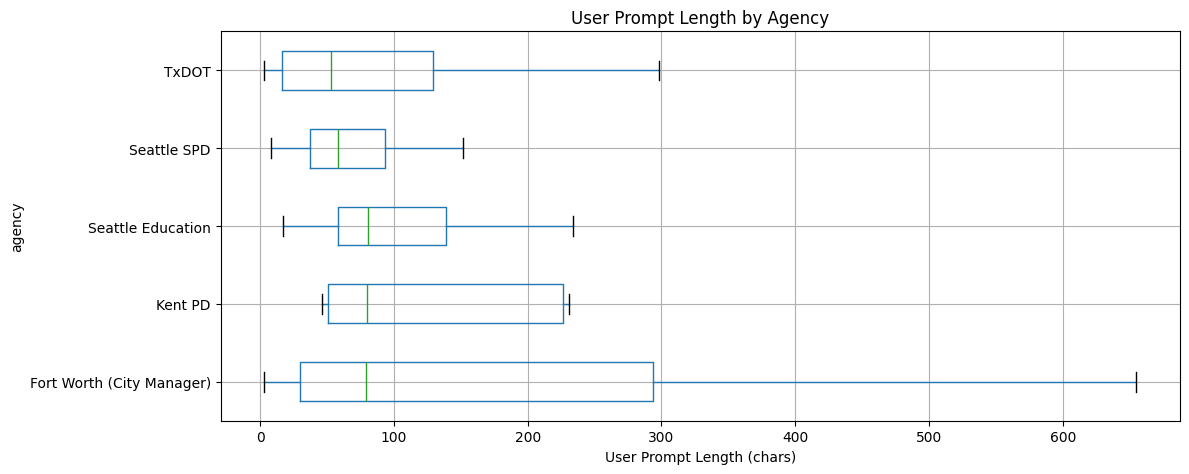

In [13]:
# Prompt length by agency
fig, ax = plt.subplots(figsize=(12, 5))
user_msgs.boxplot(column='content_len', by='agency', ax=ax, vert=False, showfliers=False)
ax.set_xlabel('User Prompt Length (chars)')
ax.set_title('User Prompt Length by Agency')
plt.suptitle('')  # Remove auto title
plt.tight_layout()
plt.show()

## 8. Temporal patterns (where timestamps available)

In [14]:
timestamped = msg_df[msg_df['timestamp'].notna()].copy()
print(f"{len(timestamped):,} messages have timestamps ({len(timestamped)/len(msg_df)*100:.1f}% of total)")
print(f"Date range: {timestamped['timestamp'].min()} — {timestamped['timestamp'].max()}")
print(f"Agencies with timestamps: {timestamped['agency'].unique().tolist()}")

8,206 messages have timestamps (88.6% of total)
Date range: 2024-09-12 16:23:00 — 2026-01-08 22:18:00
Agencies with timestamps: ['TxDOT']


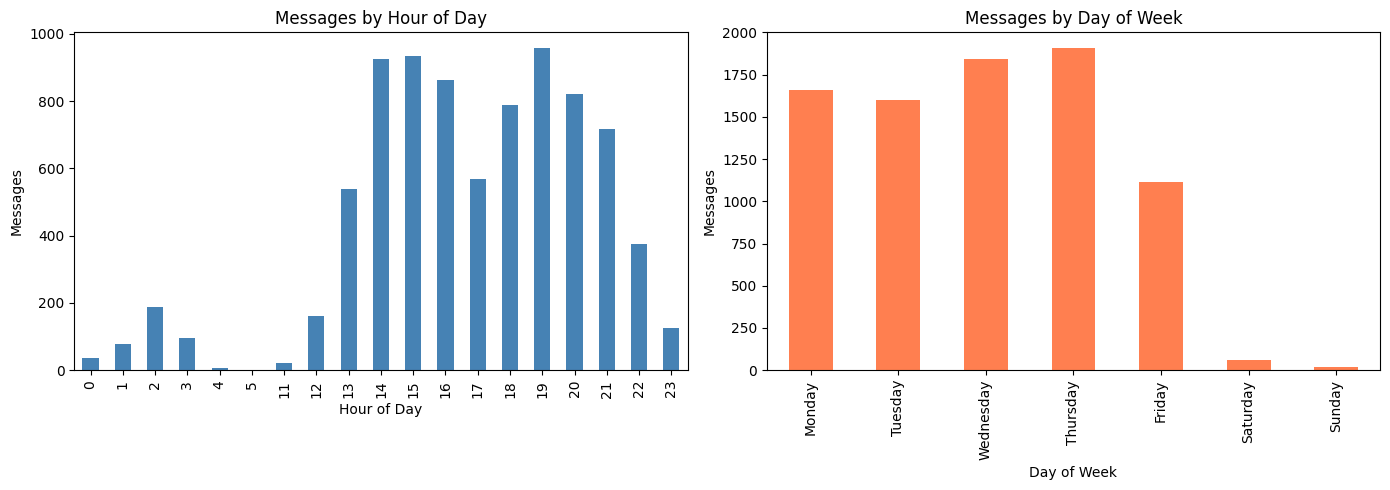

In [15]:
if len(timestamped) > 0:
    timestamped['date'] = timestamped['timestamp'].dt.date
    timestamped['hour'] = timestamped['timestamp'].dt.hour
    timestamped['dow'] = timestamped['timestamp'].dt.day_name()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Messages by hour
    timestamped['hour'].value_counts().sort_index().plot.bar(ax=ax1, color='steelblue')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Messages')
    ax1.set_title('Messages by Hour of Day')

    # Messages by day of week
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = timestamped['dow'].value_counts().reindex(dow_order)
    dow_counts.plot.bar(ax=ax2, color='coral')
    ax2.set_xlabel('Day of Week')
    ax2.set_ylabel('Messages')
    ax2.set_title('Messages by Day of Week')

    plt.tight_layout()
    plt.show()

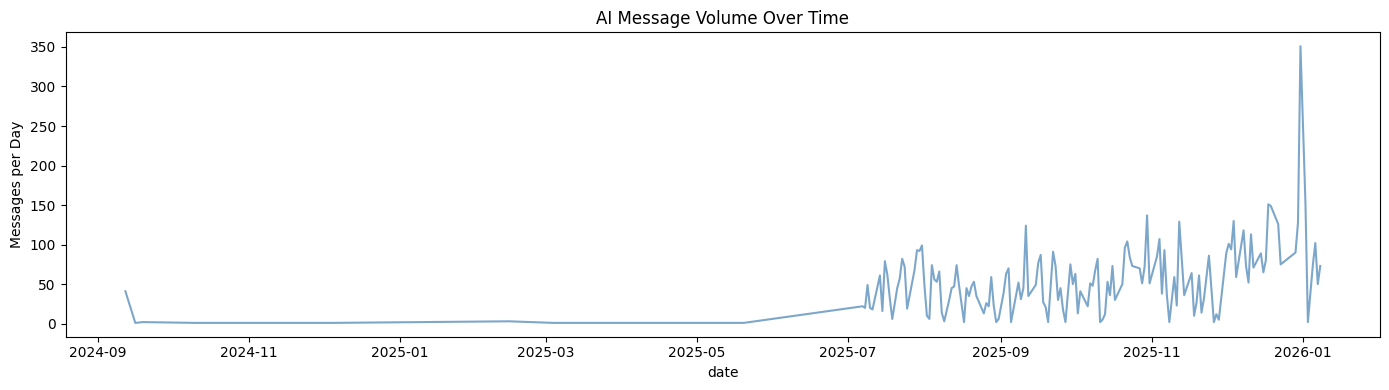

In [16]:
if len(timestamped) > 0:
    # Daily volume over time
    daily = timestamped.groupby('date').size()
    fig, ax = plt.subplots(figsize=(14, 4))
    daily.plot(ax=ax, color='steelblue', alpha=0.7)
    ax.set_ylabel('Messages per Day')
    ax.set_title('AI Message Volume Over Time')
    plt.tight_layout()
    plt.show()

## 9. Individual datapoint viewer

Browse individual conversations interactively.

In [17]:
def view_conversation(conv: Conversation, max_msg_len: int = 500):
    """Pretty-print a single conversation."""
    print(f"{'='*70}")
    print(f"Agency:  {conv.agency}")
    print(f"File:    {conv.source_file.split('/')[-1]}")
    print(f"Format:  {conv.format_type}")
    if conv.title:
        print(f"Title:   {conv.title}")
    if conv.user_name:
        print(f"User:    {conv.user_name}" + (f" <{conv.user_email}>" if conv.user_email else ""))
    if conv.ai_tool:
        print(f"AI Tool: {conv.ai_tool}")
    if conv.date:
        print(f"Date:    {conv.date}")
    print(f"Messages: {conv.num_messages} ({conv.num_user_messages} user, {conv.num_assistant_messages} assistant)")
    print(f"{'='*70}")
    for i, m in enumerate(conv.messages):
        role_label = '>>> USER' if m.role == 'user' else '<<< AI'
        ts = f"  [{m.timestamp}]" if m.timestamp else ""
        print(f"\n{role_label}{ts}")
        content = m.content
        if len(content) > max_msg_len:
            content = content[:max_msg_len] + f"... [{len(m.content) - max_msg_len} more chars]"
        print(textwrap.fill(content, width=80, initial_indent='  ', subsequent_indent='  '))
    print()

In [18]:
# Build an index for easy browsing
parseable_convos = [c for c in conversations if c.messages]
print(f"{len(parseable_convos)} browseable conversations\n")

# Group by agency for navigation
by_agency = {}
for c in parseable_convos:
    by_agency.setdefault(c.agency, []).append(c)

for agency, convos in sorted(by_agency.items()):
    print(f"  {agency}: {len(convos)} conversations")

920 browseable conversations

  Fort Worth (City Manager): 1 conversations
  Kent PD: 2 conversations
  Minneapolis PD: 2 conversations
  Seattle Education: 8 conversations
  Seattle SPD: 1 conversations
  TxDOT: 906 conversations


In [19]:
# View a sample conversation from each agency
import random
random.seed(42)

for agency in sorted(by_agency.keys()):
    convos = [c for c in by_agency[agency] if c.num_messages >= 2]
    if convos:
        view_conversation(random.choice(convos))

Agency:  Fort Worth (City Manager)
File:    ChatGPT_Data_Export_SWilliams_Redacted.pdf
Format:  pdf_chatgpt
Title:   Update on IR coordination
User:    Chat
AI Tool: ChatGPT
Messages: 319 (139 user, 180 assistant)

>>> USER
  My boss has asked that we add IR (informal reports) to the city leadership
  meetings prior to when they are scheduled to be  presented to city council.
  the problem is that the list of IRs is kept by the city secretary's office and
  while my boss would  like for both teams to work off of one spreadsheet, the
  CSO is not open to this idea. Additionally, one of my senior admin  assistants
  has probably been talking to my boss about the topic - possibly
  misrepresenting how I'm approaching the issue. My ... [1868 more chars]

<<< AI
  Your draft is already strong — it demonstrates initiative, process awareness,
  and deference to your boss’s direction. However,  you can tighten it slightly
  for polish, clarity, and tone (especially since this goes upward). Her

In [20]:
# View a specific conversation by index
# Change the agency and index to browse:
AGENCY = 'TxDOT'
INDEX = 0

if AGENCY in by_agency and INDEX < len(by_agency[AGENCY]):
    view_conversation(by_agency[AGENCY][INDEX], max_msg_len=1000)
else:
    print(f"Agency '{AGENCY}' not found or index {INDEX} out of range")

Agency:  TxDOT
File:    2025_TMUTCD_Reverse_School_Zone_Beacon_Rules.html
Format:  html_copilot
Title:   2025 TMUTCD Reverse School Zone Beacon Rules
User:    Cody Thomas <Cody.Thomas@txdot.gov>
AI Tool: Microsoft 365 Chat
Date:    2025-12-11 21:58:00
Messages: 6 (2 user, 4 assistant)

>>> USER  [2025-12-11 21:58:00]
  Can you find in the 2025 TMUTCD where it talks about the reverse school zone
  beacon and the reverse that goes with it? I am trying to determine if that is
  an optional/recommended/required feature

<<< AI  [2025-12-11 21:58:00]
  OK, I'll search for '2025 TMUTCD reverse school zone beacon optional
  recommended required'...

<<< AI  [2025-12-11 21:58:00]
  TMUTCD 2025.pdfTMUTCD 2011 (2014 Rev. 2).pdf2025 SJT TxTAP Report.pdf2025 SAT
  TxTAP Report.pdfunknown-file-name2025 SJT TxTAP Report.pdf2025 HOU TxTAP
  Report.pdf2025 DAL TxTAP Report.pdf2025 AUS TxTAP
  Report.pdfTCRT_2025_FTW_Memo_and_Report.pdfYou asked about where the **2025
  TMUTCD** addresses the *reverse 

## 10. Search across all conversations

In [21]:
def search_conversations(query: str, conversations: list, role: str = None, max_results: int = 10):
    """Search for a keyword/phrase across all conversations."""
    results = []
    query_lower = query.lower()
    for c in conversations:
        for m in c.messages:
            if role and m.role != role:
                continue
            if query_lower in m.content.lower():
                # Find the matching snippet
                idx = m.content.lower().index(query_lower)
                start = max(0, idx - 100)
                end = min(len(m.content), idx + len(query) + 100)
                snippet = ('...' if start > 0 else '') + m.content[start:end] + ('...' if end < len(m.content) else '')
                results.append({
                    'agency': c.agency,
                    'user': c.user_name,
                    'title': c.title,
                    'role': m.role,
                    'snippet': snippet,
                    'conversation': c,
                })
                if len(results) >= max_results:
                    break
        if len(results) >= max_results:
            break
    return results

In [22]:
# Example: search for a keyword
QUERY = 'policy'  # Change this to search for anything

results = search_conversations(QUERY, parseable_convos, max_results=10)
print(f"Found {len(results)} matches for '{QUERY}':\n")
for r in results:
    print(f"  [{r['agency']}] {r['role'].upper()} — {r['user'] or 'unknown'}")
    print(f"    {r['snippet'][:150]}")
    print()

Found 10 matches for 'policy':

  [TxDOT] ASSISTANT — Cody Thomas
    ...ps://go.microsoft.com/fwlink/?linkid=2171883","complianceChecks":{"connectedExperiences":"Enabled","policyAllowFeedback":"Not Configured","policyAl

  [TxDOT] ASSISTANT — Cody Thomas
    ...ps://go.microsoft.com/fwlink/?linkid=2171883","complianceChecks":{"connectedExperiences":"Enabled","policyAllowFeedback":"Not Configured","policyAl

  [TxDOT] ASSISTANT — Cody Thomas
    ...ps://go.microsoft.com/fwlink/?linkid=2171883","complianceChecks":{"connectedExperiences":"Enabled","policyAllowFeedback":"Not Configured","policyAl

  [TxDOT] ASSISTANT — Cody Thomas
    ...ps://go.microsoft.com/fwlink/?linkid=2171883","complianceChecks":{"connectedExperiences":"Enabled","policyAllowFeedback":"Not Configured","policyAl

  [TxDOT] ASSISTANT — Cody Thomas
    ...ps://go.microsoft.com/fwlink/?linkid=2171883","complianceChecks":{"connectedExperiences":"Enabled","policyAllowFeedback":"Not Configured","policyAl

  [TxDOT] ASSISTAN

In [23]:
# View full conversation for a search result (change index)
RESULT_INDEX = 0
if results:
    view_conversation(results[RESULT_INDEX]['conversation'])

Agency:  TxDOT
File:    Are_you_able_to_reformat_this_document.html
Format:  html_copilot
Title:   Are you able to reformat this document
User:    Cody Thomas <Cody.Thomas@txdot.gov>
AI Tool: Copilot in Word
Date:    2025-07-29 03:04:00
Messages: 7 (4 user, 3 assistant)

>>> USER  [2025-07-29 03:04:00]
  Resume_2025 B.E.
  App.docx{"messageType":5,"body":{"user":"human","message":"Are you able to
  reformat this document?","disableLinksProcessing":true,"shouldApplyInputLinkTh
  eme":true,"commandText":"Are you able to reformat this document?","hydratedEnt
  ities":[]},"feedbackData":{"feedbackArea":"Copilot","contextData":{"cardMetaDa
  ta":"{\"prompt\":\"Are you able to reformat this
  document?\",\"promptId\":\"289c8cea-ac9d-4f99-a1ae-
  76ca69d12570\",\"enabledPlugins\":[\"BingWebSearch\",\"EnterpriseSearch\"]...
  [913 more chars]

>>> USER  [2025-07-29 03:04:00]
  Resume_2025 B.E.
  App.docx{"messageType":5,"body":{"user":"human","message":"Are you able to
  reformat this document

## 11. Common user prompt patterns

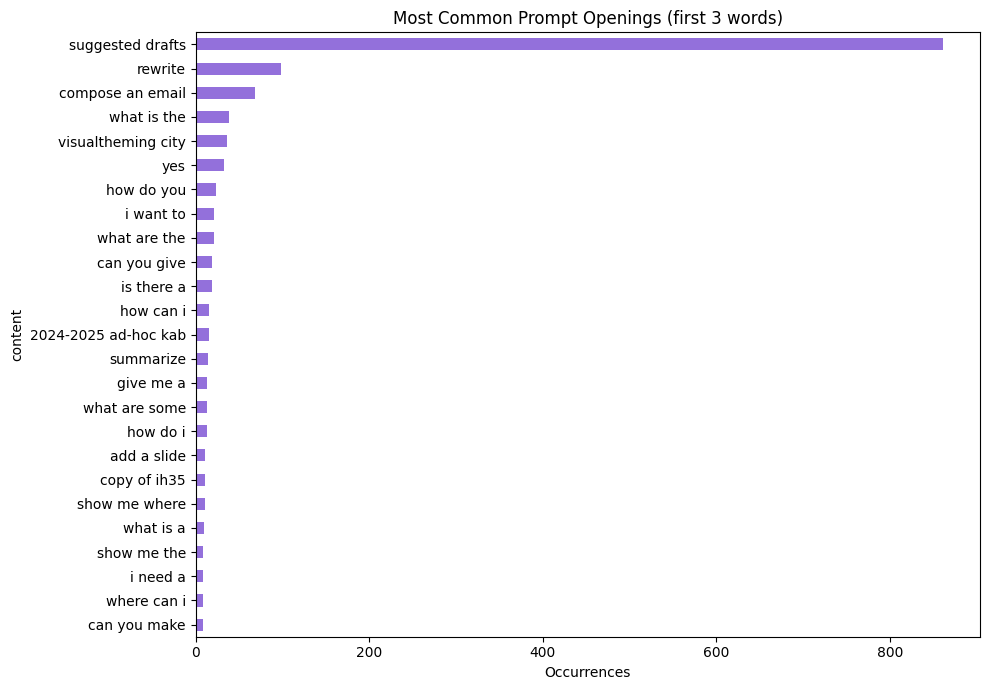

In [24]:
# Analyze first words of user prompts to find common patterns
user_prompts = msg_df[msg_df['role'] == 'user']['content'].dropna()

# First 3 words
first_words = user_prompts.str.split().str[:3].str.join(' ').str.lower()
common_starts = first_words.value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 7))
common_starts.plot.barh(ax=ax, color='mediumpurple')
ax.set_xlabel('Occurrences')
ax.set_title('Most Common Prompt Openings (first 3 words)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

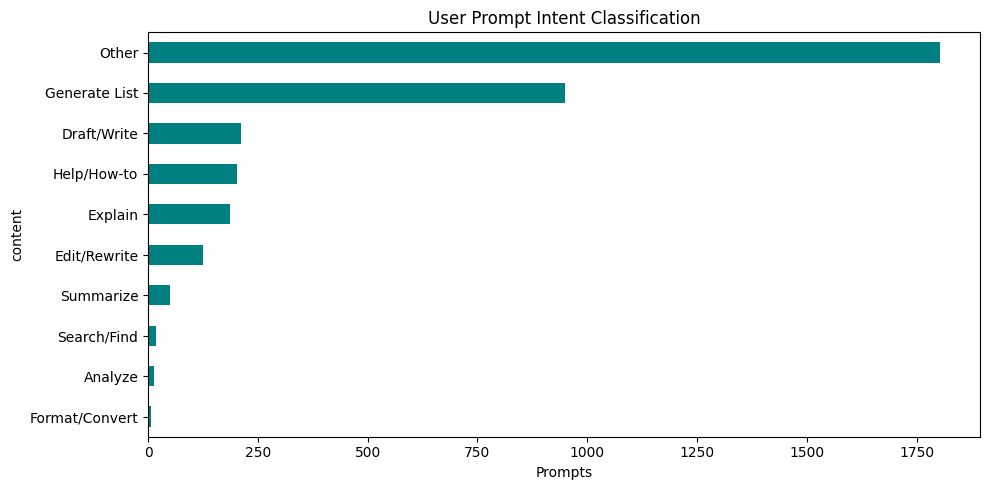

In [25]:
# Classify prompts by intent
INTENT_PATTERNS = {
    'Draft/Write': r'^(write|draft|compose|create a|make a)',
    'Summarize': r'^(summarize|sum up|give me a summary|tldr)',
    'Explain': r'^(explain|what is|what are|what does|how does|why)',
    'Analyze': r'^(analyze|analy[sz]e|compare|review|evaluate)',
    'Edit/Rewrite': r'^(rewrite|edit|revise|improve|fix|correct|proofread)',
    'Generate List': r'^(list|give me|provide|suggest|recommend)',
    'Format/Convert': r'^(format|convert|reformat|transform|translate)',
    'Search/Find': r'^(find|search|look up|can you find)',
    'Help/How-to': r'^(help|how (do|can|would|should)|can you)',
}

def classify_intent(text):
    if not text:
        return 'Other'
    text_lower = text.lower().strip()
    for intent, pattern in INTENT_PATTERNS.items():
        if re.match(pattern, text_lower):
            return intent
    return 'Other'

intent_series = user_prompts.apply(classify_intent)

fig, ax = plt.subplots(figsize=(10, 5))
intent_series.value_counts().plot.barh(ax=ax, color='teal')
ax.set_xlabel('Prompts')
ax.set_title('User Prompt Intent Classification')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Conversation depth analysis

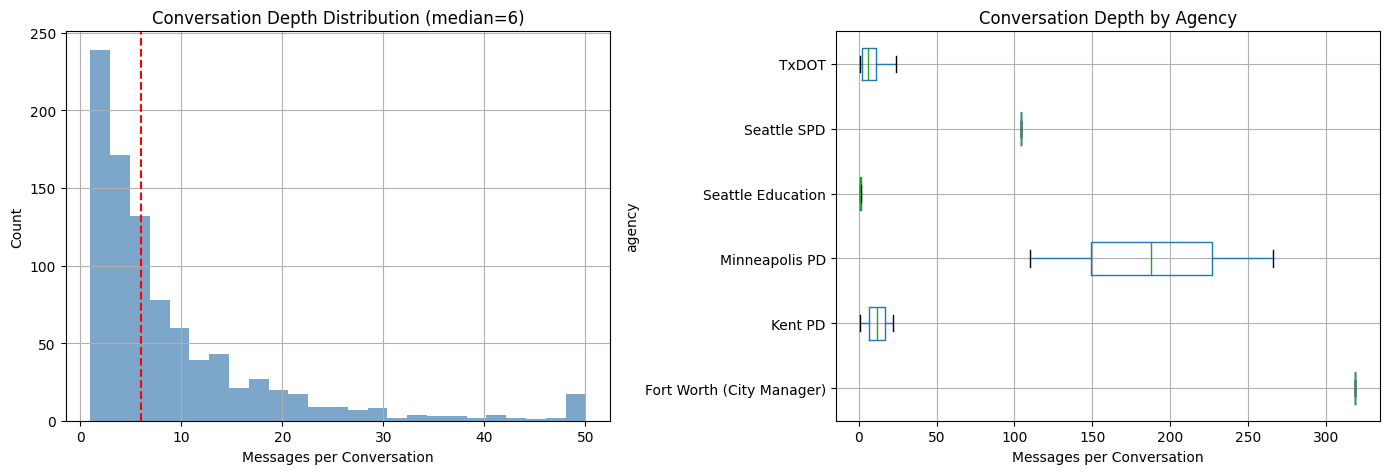

Longest conversations:


,agency,user_name,num_messages,total_chars
935,Fort Worth (City Manager),Chat,319,800065
927,Minneapolis PD,None,266,427930
917,Seattle Education,Swift,223,246626
362,TxDOT,Cody Thomas,140,80316
20,TxDOT,Cody Thomas,112,143175
926,Minneapolis PD,None,110,109909
907,Seattle SPD,None,104,100699
99,TxDOT,Cody Thomas,83,94362
21,TxDOT,Cody Thomas,73,98255
128,TxDOT,Cody Thomas,65,110395


In [26]:
# How many turns do conversations typically have?
convo_lengths = conv_df[conv_df['has_content']]['num_messages']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

convo_lengths.clip(upper=50).hist(ax=ax1, bins=25, color='steelblue', alpha=0.7)
ax1.set_xlabel('Messages per Conversation')
ax1.set_ylabel('Count')
ax1.set_title(f'Conversation Depth Distribution (median={convo_lengths.median():.0f})')
ax1.axvline(convo_lengths.median(), color='red', linestyle='--')

# By agency
conv_df[conv_df['has_content']].boxplot(column='num_messages', by='agency', ax=ax2, vert=False, showfliers=False)
ax2.set_xlabel('Messages per Conversation')
ax2.set_title('Conversation Depth by Agency')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Longest conversations:")
longest = conv_df[conv_df['has_content']].nlargest(10, 'num_messages')[['agency', 'user_name', 'num_messages', 'total_chars']]
longest

## 13. Data quality summary

In [27]:
quality = pd.DataFrame({
    'Total entries': conv_df.groupby('agency').size(),
    'Parseable': conv_df[conv_df['has_content']].groupby('agency').size(),
    'Has user name': conv_df[conv_df['user_name'].notna()].groupby('agency').size(),
    'Has timestamp': conv_df[conv_df['date'].notna()].groupby('agency').size(),
    'Has title': conv_df[conv_df['title'].notna()].groupby('agency').size(),
}).fillna(0).astype(int)

quality['Parse rate'] = (quality['Parseable'] / quality['Total entries'] * 100).round(1).astype(str) + '%'
quality

,Total entries,Parseable,Has user name,Has timestamp,Has title,Parse rate
agency,,,,,,
CFPB,2,0,0,0,1,0.0%
CFTC,2,0,0,0,1,0.0%
Fort Worth (City Attorney),5,0,0,0,3,0.0%
Fort Worth (City Manager),7,1,1,0,6,14.3%
Kent PD,6,2,2,0,3,33.3%
Minneapolis PD,2,2,0,0,0,100.0%
SEC,2,0,0,0,1,0.0%
Seattle Education,8,8,8,0,0,100.0%
Seattle SPD,4,1,0,0,2,25.0%
